In [1]:
pip install pandas numpy scikit-learn xgboost shap imbalanced-learn matplotlib seaborn joblib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.2/559.2 kB 1.4 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.3/258.3 kB 1.5 MB/s eta 0:00:0000:0100:01
  Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
  Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 1.9 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.1/31.1 MB 6.0 MB/s eta 0:00:0000:0100:01m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.8/19.8 MB 5.3 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.38.0
    Uninstalling llvmlite-0.38.0:
      Successfully uninstalled llvmlite-0.38.0
  Attempting uninstall: joblib
    Found existing installation: joblib 1.1.0
    Uninstalling joblib-1.1.0:
      Successfully uninst

In [7]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130, 'figure.figsize': (10, 5)})

print('✅ All libraries loaded successfully.')

✅ All libraries loaded successfully.


In [8]:
df = pd.read_csv('/Users/marselahalili/Desktop/Churn_Project/customer_churn_business_dataset.csv')

print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
print(f'\nColumn names:\n{df.columns.tolist()}')

Rows: 10,000
Columns: 32

Column names:
['customer_id', 'gender', 'age', 'country', 'city', 'customer_segment', 'tenure_months', 'signup_channel', 'contract_type', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_method', 'payment_failures', 'discount_applied', 'price_increase_last_3m', 'support_tickets', 'avg_resolution_time', 'complaint_type', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'survey_response', 'referral_count', 'churn']


In [9]:
df.head()

,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,...,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,...,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,...,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0
3,CUST_00004,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,...,26.420822,Technical,5.0,1,0.83,0.15,100,Neutral,0,0
4,CUST_00005,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,...,26.674579,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0


In [10]:
info = pd.DataFrame({
    'dtype':      df.dtypes,
    'null_count': df.isnull().sum(),
    'null_%':     (df.isnull().mean() * 100).round(2),
    'unique_vals': df.nunique()
})
print(info.to_string())

                          dtype  null_count  null_%  unique_vals
customer_id              object           0    0.00        10000
gender                   object           0    0.00            2
age                       int64           0    0.00           57
country                  object           0    0.00            7
city                     object           0    0.00            7
customer_segment         object           0    0.00            3
tenure_months             int64           0    0.00           59
signup_channel           object           0    0.00            3
contract_type            object           0    0.00            3
monthly_logins            int64           0    0.00           53
weekly_active_days        int64           0    0.00            8
avg_session_time        float64           0    0.00         9777
features_used             int64           0    0.00           15
usage_growth_rate       float64           0    0.00          104
last_login_days_ago      

In [11]:
# Fill missing complaint_type — null means the customer never complained
df['complaint_type'] = df['complaint_type'].fillna('No Complaint')

print(f'Nulls remaining: {df.isnull().sum().sum()}')
print(f'\ncomplaint_type values:\n{df["complaint_type"].value_counts()}')

Nulls remaining: 0

complaint_type values:
complaint_type
Technical       3498
Billing         2427
No Complaint    2045
Service         2030
Name: count, dtype: int64


Churn Distribution:
       Count  Percentage
churn                   
0       8979       89.79
1       1021       10.21


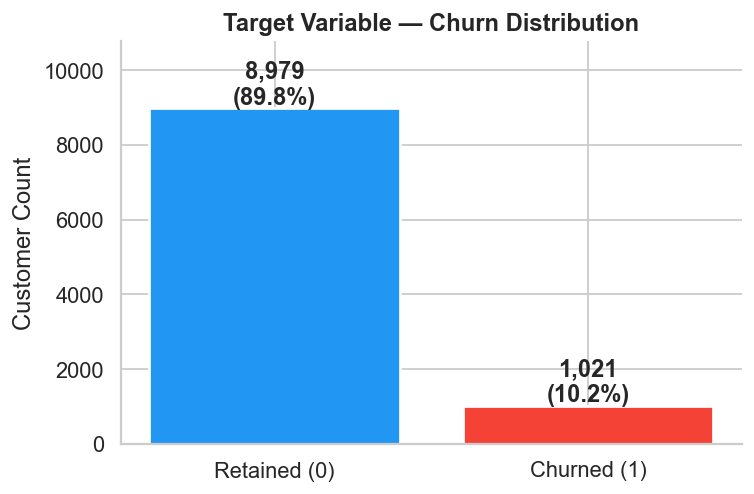

In [12]:
churn_counts = df['churn'].value_counts()
churn_pct = df['churn'].value_counts(normalize=True) * 100

print('Churn Distribution:')
print(pd.DataFrame({'Count': churn_counts, 'Percentage': churn_pct.round(2)}))

plt.figure(figsize=(6, 4))
plt.bar(['Retained (0)', 'Churned (1)'], churn_counts.values,
        color=['#2196F3', '#F44336'], edgecolor='white', linewidth=1.5)
for i, (count, pct) in enumerate(zip(churn_counts.values, churn_pct.values)):
    plt.text(i, count + 100, f'{count:,}\n({pct:.1f}%)', ha='center', fontweight='bold')
plt.title('Target Variable — Churn Distribution', fontweight='bold')
plt.ylabel('Customer Count')
plt.ylim(0, max(churn_counts.values) * 1.2)
sns.despine()
plt.tight_layout()
plt.show()

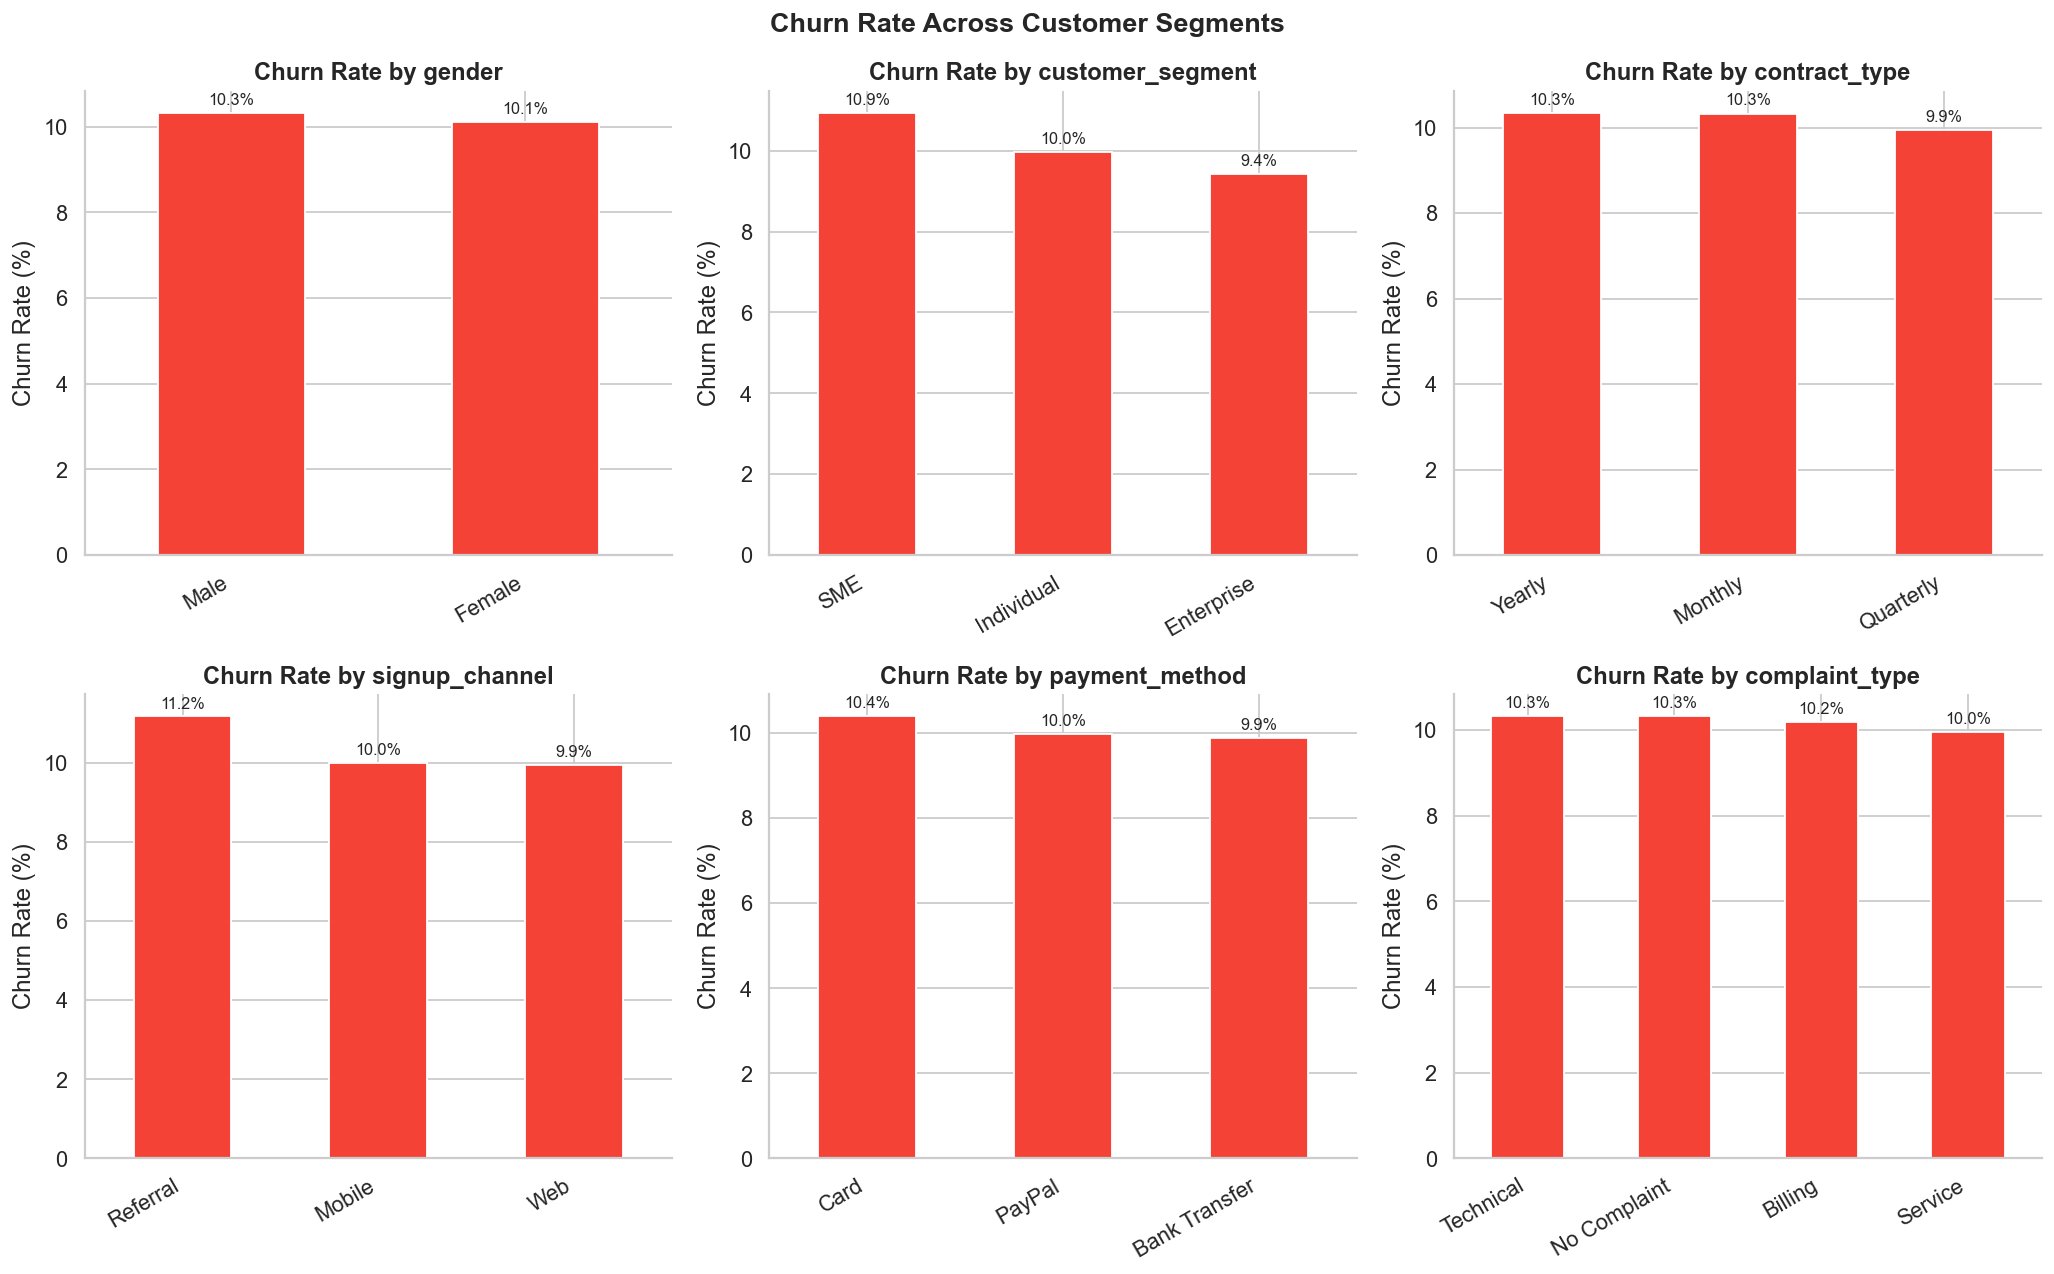

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

cat_cols = ['gender', 'customer_segment', 'contract_type', 
            'signup_channel', 'payment_method', 'complaint_type']

for i, col in enumerate(cat_cols):
    rates = df.groupby(col)['churn'].mean() * 100
    rates.sort_values(ascending=False).plot(
        kind='bar', ax=axes[i], color='#F44336', edgecolor='white'
    )
    axes[i].set_title(f'Churn Rate by {col}', fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')
    for bar in axes[i].patches:
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                     f'{bar.get_height():.1f}%', ha='center', fontsize=9)

plt.suptitle('Churn Rate Across Customer Segments', fontsize=15, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

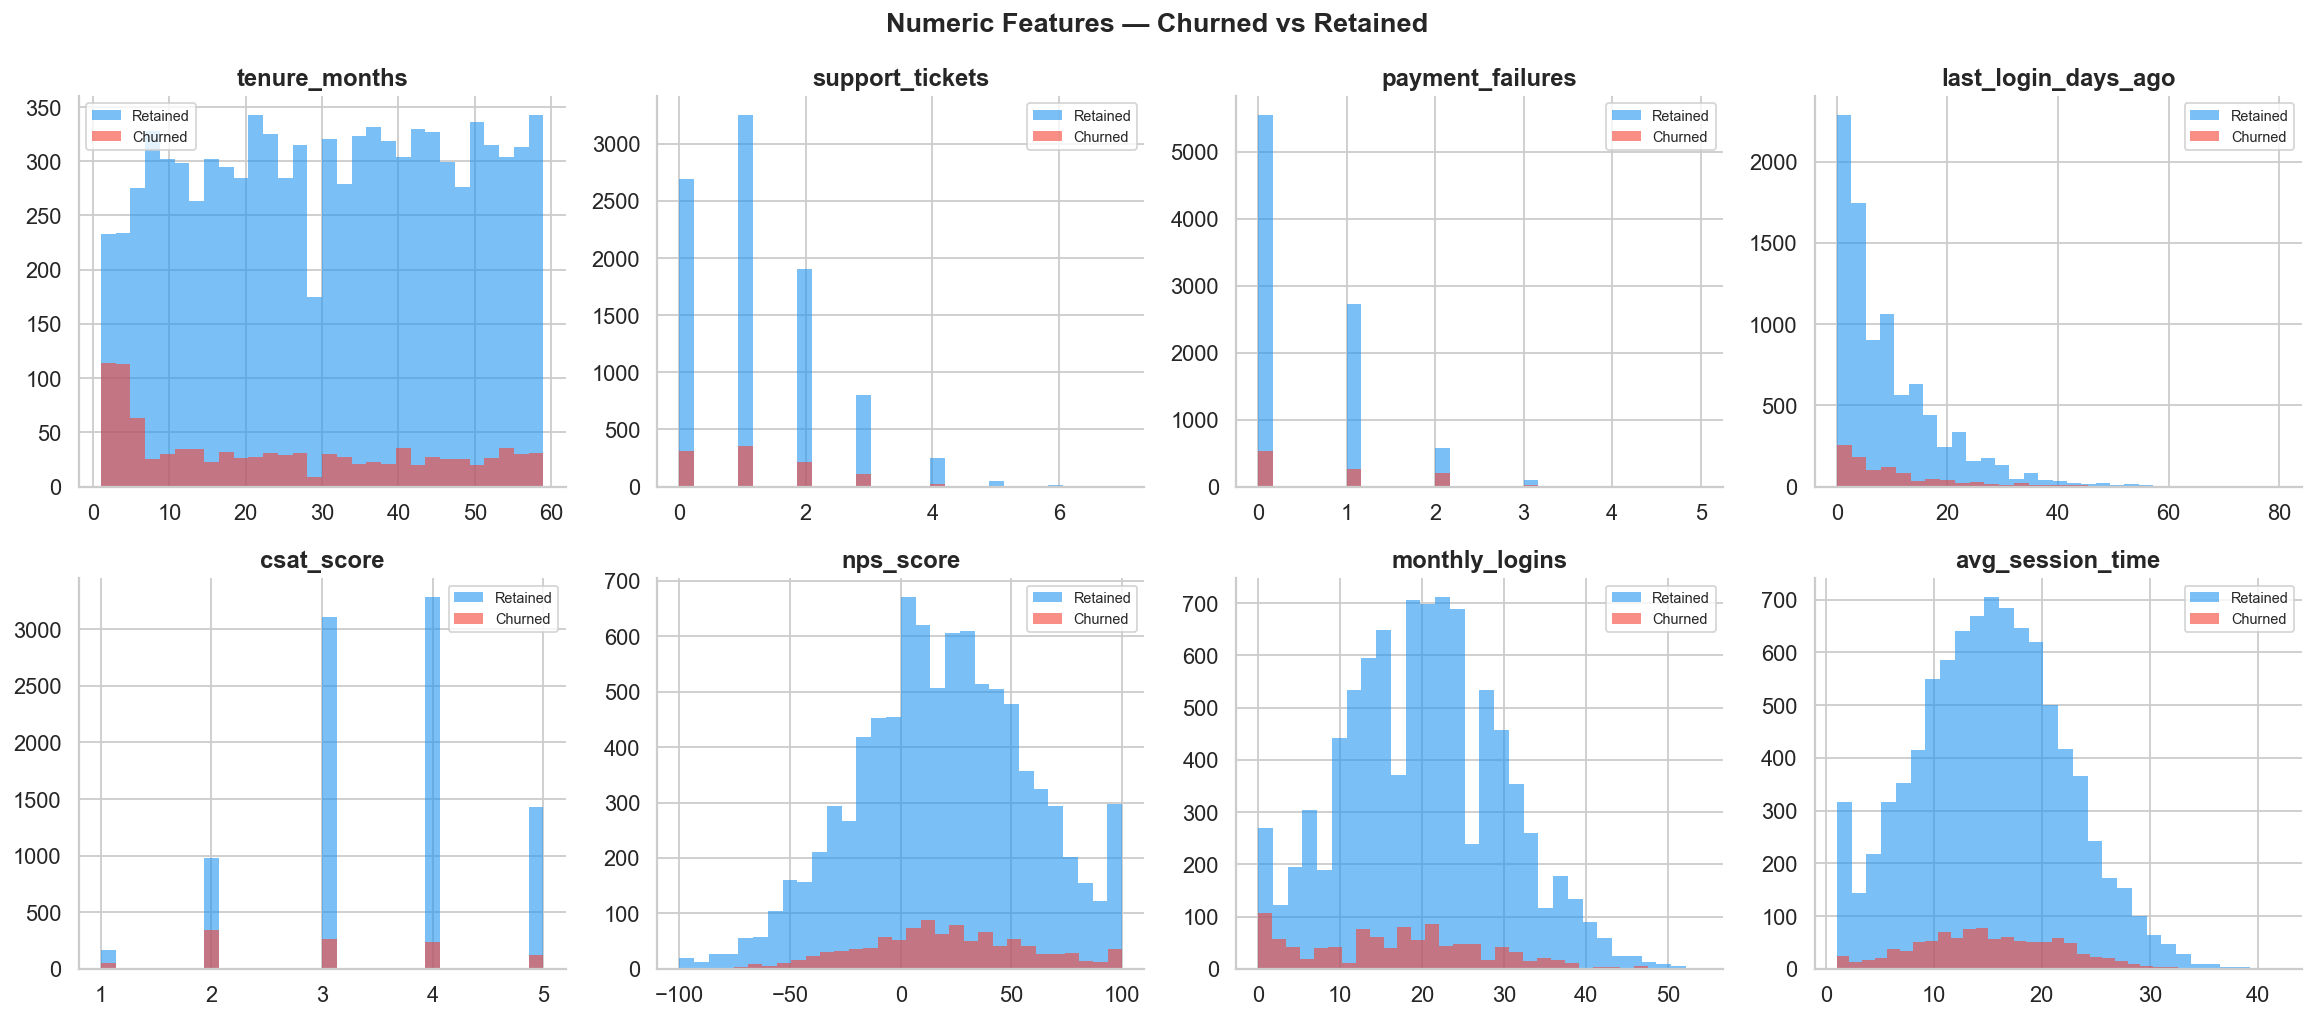

In [15]:
num_cols = ['tenure_months', 'support_tickets', 'payment_failures',
            'last_login_days_ago', 'csat_score', 'nps_score',
            'monthly_logins', 'avg_session_time']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[df['churn']==0][col], bins=30, alpha=0.6, 
                 label='Retained', color='#2196F3', edgecolor='none')
    axes[i].hist(df[df['churn']==1][col], bins=30, alpha=0.6, 
                 label='Churned', color='#F44336', edgecolor='none')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Numeric Features — Churned vs Retained', fontsize=15, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

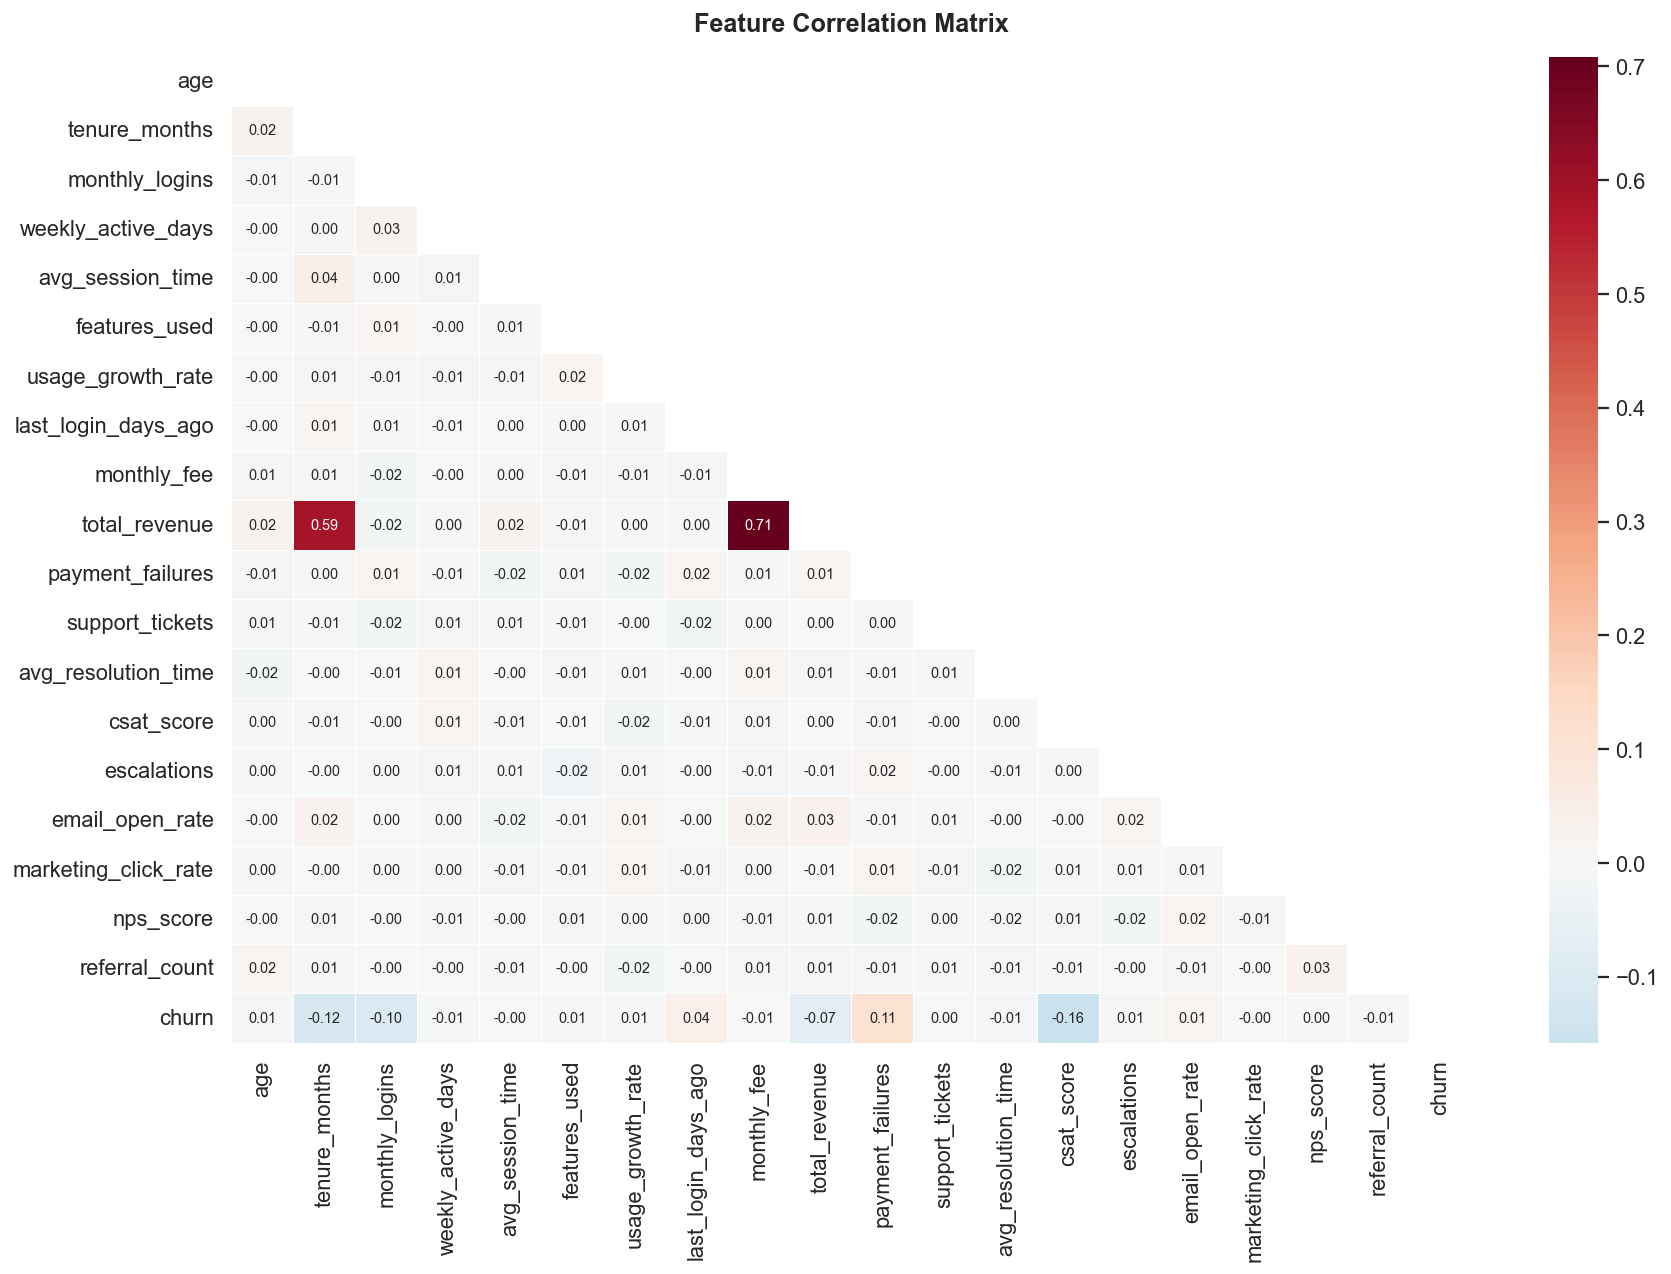

In [16]:
num_all = df.select_dtypes(include=np.number).columns.tolist()

corr = df[num_all].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, linewidths=0.5,
    ax=ax, annot_kws={'size': 8}
)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=14)
plt.tight_layout()
plt.show()

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

# Drop ID column — not useful for modelling
df_model = df.drop(columns=['customer_id'])

# Encode all categorical columns as numbers
le = LabelEncoder()
cat_cols = df_model.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print('Encoded columns:', cat_cols)
print(f'\nDataset shape after encoding: {df_model.shape}')
df_model.head()

Encoded columns: ['gender', 'country', 'city', 'customer_segment', 'signup_channel', 'contract_type', 'payment_method', 'discount_applied', 'price_increase_last_3m', 'complaint_type', 'survey_response']

Dataset shape after encoding: (10000, 31)


,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,weekly_active_days,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,1,68,1,3,2,22,2,0,26,7,...,13.354360,2,4.0,0,0.71,0.40,27,1,1,0
1,0,57,2,5,1,9,0,0,7,5,...,25.140088,0,2.0,0,0.78,0.33,-19,0,2,1
2,1,24,3,4,2,58,2,2,19,5,...,27.572928,2,3.0,0,0.35,0.49,80,0,1,0
3,1,49,0,2,1,19,0,2,34,7,...,26.420822,3,5.0,1,0.83,0.15,100,0,0,0
4,1,65,1,1,1,52,2,0,20,6,...,26.674579,3,4.0,0,0.65,0.44,21,2,1,0


In [20]:
# Separate features (X) from target (y)
X = df_model.drop(columns=['churn'])
y = df_model['churn']

print(f'Features: {X.shape}')
print(f'Target:   {y.shape}')

# Train/test split — 80% train, 20% test, stratified to keep churn ratio equal
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTrain set: {X_train.shape}')
print(f'Test set:  {X_test.shape}')
print(f'Train churn rate: {y_train.mean():.2%}')
print(f'Test churn rate:  {y_test.mean():.2%}')

# Scale numeric features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Apply SMOTE to training set only — never touch the test set
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_sc, y_train)

print(f'\nBefore SMOTE: {dict(y_train.value_counts())}')
print(f'After  SMOTE: {dict(pd.Series(y_train_bal).value_counts())}')

Features: (10000, 30)
Target:   (10000,)

Train set: (8000, 30)
Test set:  (2000, 30)
Train churn rate: 10.21%
Test churn rate:  10.20%

Before SMOTE: {0: 7183, 1: 817}
After  SMOTE: {0: 7183, 1: 7183}


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_bal, y_train_bal)

y_pred_lr  = lr.predict(X_test_sc)
y_proba_lr = lr.predict_proba(X_test_sc)[:, 1]

print('=== Logistic Regression — Baseline ===')
print(classification_report(y_test, y_pred_lr, target_names=['Retained', 'Churned']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_proba_lr):.4f}')

=== Logistic Regression — Baseline ===
              precision    recall  f1-score   support

    Retained       0.94      0.68      0.79      1796
     Churned       0.19      0.65      0.29       204

    accuracy                           0.68      2000
   macro avg       0.57      0.66      0.54      2000
weighted avg       0.87      0.68      0.74      2000

AUC-ROC: 0.7216


In [24]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train_bal, y_train_bal)

y_pred_xgb  = xgb.predict(X_test_sc)
y_proba_xgb = xgb.predict_proba(X_test_sc)[:, 1]

print('=== XGBoost — Initial ===')
print(classification_report(y_test, y_pred_xgb, target_names=['Retained', 'Churned']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_proba_xgb):.4f}')

=== XGBoost — Initial ===
              precision    recall  f1-score   support

    Retained       0.90      0.98      0.94      1796
     Churned       0.24      0.05      0.09       204

    accuracy                           0.89      2000
   macro avg       0.57      0.52      0.51      2000
weighted avg       0.83      0.89      0.85      2000

AUC-ROC: 0.7838


In [25]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [3, 5, 7],
    'learning_rate':    [0.05, 0.1],
    'subsample':        [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42),
    param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_bal, y_train_bal)

print(f'\nBest Parameters: {grid_search.best_params_}')
print(f'Best CV AUC-ROC: {grid_search.best_score_:.4f}')

best_xgb = grid_search.best_estimator_

Fitting 5 folds for each of 72 candidates, totalling 360 fits


/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NU


Best Parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.7}
Best CV AUC-ROC: 0.9838


In [26]:
y_pred_best  = best_xgb.predict(X_test_sc)
y_proba_best = best_xgb.predict_proba(X_test_sc)[:, 1]

print('=== XGBoost — Tuned Champion ===')
print(classification_report(y_test, y_pred_best, target_names=['Retained', 'Churned']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_proba_best):.4f}')

=== XGBoost — Tuned Champion ===
              precision    recall  f1-score   support

    Retained       0.90      0.99      0.94      1796
     Churned       0.18      0.02      0.04       204

    accuracy                           0.89      2000
   macro avg       0.54      0.51      0.49      2000
weighted avg       0.83      0.89      0.85      2000

AUC-ROC: 0.7802


In [27]:
from sklearn.metrics import f1_score

# Try different thresholds and find the best one for catching churners
thresholds = np.linspace(0.01, 0.5, 100)
best_f1, best_threshold = 0, 0.5

for t in thresholds:
    preds = (y_proba_best >= t).astype(int)
    f1 = f1_score(y_test, preds, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f'Optimal threshold: {best_threshold:.3f}')
print(f'Best F1 at that threshold: {best_f1:.4f}')

# Apply optimal threshold
y_pred_tuned = (y_proba_best >= best_threshold).astype(int)

print('\n=== XGBoost — Tuned Champion + Optimal Threshold ===')
print(classification_report(y_test, y_pred_tuned, target_names=['Retained', 'Churned']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_proba_best):.4f}')

Optimal threshold: 0.099
Best F1 at that threshold: 0.3674

=== XGBoost — Tuned Champion + Optimal Threshold ===
              precision    recall  f1-score   support

    Retained       0.97      0.72      0.83      1796
     Churned       0.24      0.77      0.37       204

    accuracy                           0.73      2000
   macro avg       0.60      0.75      0.60      2000
weighted avg       0.89      0.73      0.78      2000

AUC-ROC: 0.7802


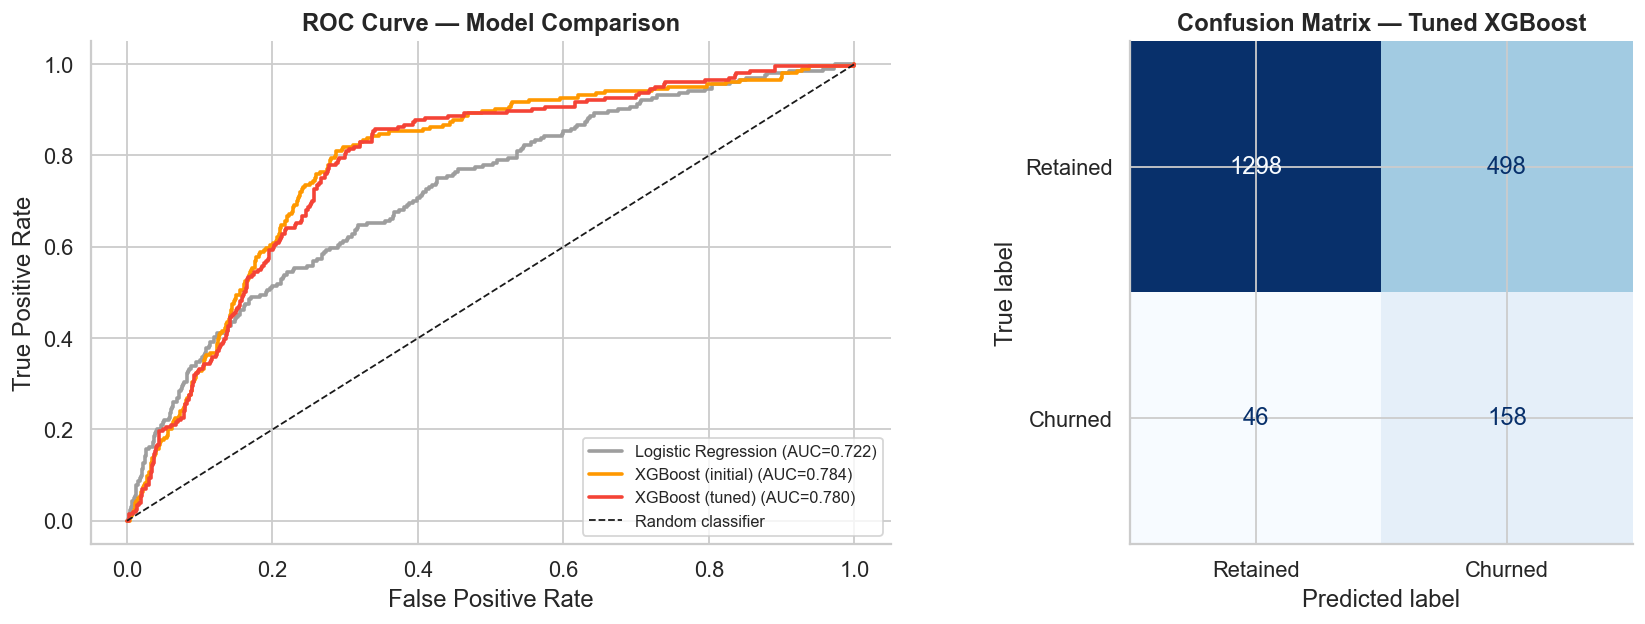

Business Impact:
  Churners correctly caught: 158 / 204 (77%)
  Churners missed: 46 / 204 (23%)
  False alarms: 498


In [29]:
from sklearn.metrics import roc_curve, confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curves
ax = axes[0]
models = [
    ('Logistic Regression', y_proba_lr,  '#9E9E9E'),
    ('XGBoost (initial)',   y_proba_xgb, '#FF9800'),
    ('XGBoost (tuned)',     y_proba_best,'#F44336'),
]
for name, proba, color in models:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)

ax.plot([0,1],[0,1], 'k--', linewidth=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Model Comparison', fontweight='bold')
ax.legend(fontsize=9)

# Confusion Matrix
ax2 = axes[1]
cm = confusion_matrix(y_test, y_pred_tuned)
ConfusionMatrixDisplay(cm, display_labels=['Retained', 'Churned']).plot(
    ax=ax2, cmap='Blues', colorbar=False
)
ax2.set_title('Confusion Matrix — Tuned XGBoost', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Business Impact:')
print(f'  Churners correctly caught: {tp} / {tp+fn} ({tp/(tp+fn):.0%})')
print(f'  Churners missed: {fn} / {tp+fn} ({fn/(tp+fn):.0%})')
print(f'  False alarms: {fp}')

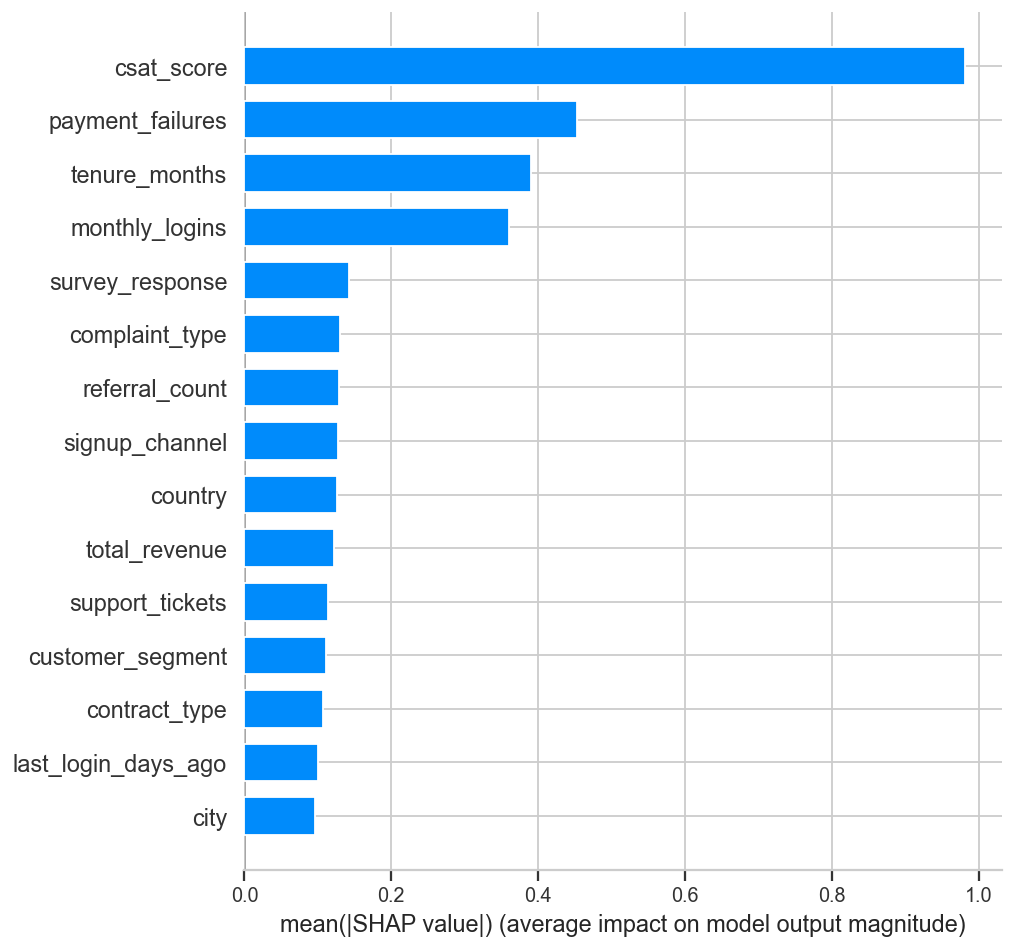

In [33]:
import shap

explainer   = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_sc)

X_test_df = pd.DataFrame(X_test_sc, columns=X.columns)

# Global feature importance
shap.summary_plot(
    shap_values, X_test_df,
    plot_type='bar',
    max_display=15,
    show=True
)

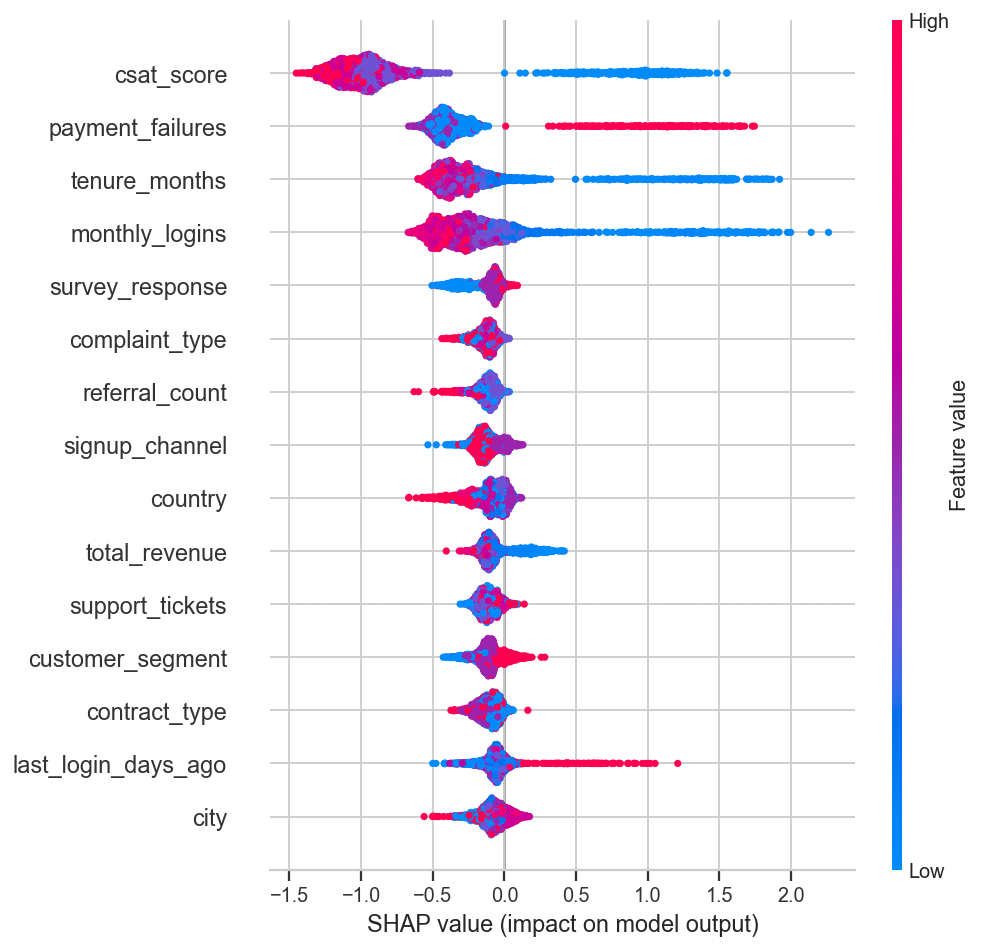

In [34]:
shap.summary_plot(
    shap_values, X_test_df,
    max_display=15,
    show=True
)

In [35]:
import joblib
import os

os.makedirs('models', exist_ok=True)

joblib.dump(best_xgb, 'models/xgboost_churn_model.pkl')
joblib.dump(scaler,   'models/scaler.pkl')
joblib.dump(X.columns.tolist(), 'models/feature_names.pkl')

print('✅ Model saved successfully:')
print('   models/xgboost_churn_model.pkl')
print('   models/scaler.pkl')
print('   models/feature_names.pkl')

✅ Model saved successfully:
   models/xgboost_churn_model.pkl
   models/scaler.pkl
   models/feature_names.pkl


In [1]:
%%writefile /Users/marselahalili/Desktop/Churn_Project/app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

st.set_page_config(
    page_title='Customer Churn Predictor',
    page_icon='🔮',
    layout='wide'
)

@st.cache_resource
def load_model():
    model    = joblib.load('models/xgboost_churn_model.pkl')
    scaler   = joblib.load('models/scaler.pkl')
    features = joblib.load('models/feature_names.pkl')
    return model, scaler, features

model, scaler, feature_names = load_model()

st.title('🔮 Customer Churn Predictor')
st.markdown('Enter a customer profile below to predict their churn risk.')
st.divider()

st.sidebar.header('Customer Profile')

gender           = st.sidebar.selectbox('Gender', ['Male', 'Female'])
age              = st.sidebar.slider('Age', 18, 80, 35)
country          = st.sidebar.selectbox('Country', ['USA', 'UK', 'Germany', 'France', 'Canada', 'Australia', 'India'])
city             = st.sidebar.selectbox('City', ['New York', 'London', 'Berlin', 'Paris', 'Toronto', 'Sydney', 'Mumbai'])
customer_segment = st.sidebar.selectbox('Customer Segment', ['SME', 'Individual', 'Enterprise'])
tenure_months    = st.sidebar.slider('Tenure (months)', 1, 60, 12)
signup_channel   = st.sidebar.selectbox('Signup Channel', ['Web', 'Mobile', 'Referral'])
contract_type    = st.sidebar.selectbox('Contract Type', ['Monthly', 'Quarterly', 'Yearly'])

st.sidebar.divider()

monthly_logins       = st.sidebar.slider('Monthly Logins', 0, 50, 15)
weekly_active_days   = st.sidebar.slider('Weekly Active Days', 0, 7, 3)
avg_session_time     = st.sidebar.slider('Avg Session Time (min)', 0.0, 40.0, 15.0)
features_used        = st.sidebar.slider('Features Used', 1, 15, 5)
usage_growth_rate    = st.sidebar.slider('Usage Growth Rate', -50.0, 50.0, 0.0)
last_login_days_ago  = st.sidebar.slider('Last Login (days ago)', 0, 70, 7)

st.sidebar.divider()

monthly_fee            = st.sidebar.selectbox('Monthly Fee ($)', [10, 20, 30, 40, 50, 60])
total_revenue          = st.sidebar.number_input('Total Revenue ($)', 0, 5000, 500)
payment_method         = st.sidebar.selectbox('Payment Method', ['Card', 'PayPal', 'Bank Transfer'])
payment_failures       = st.sidebar.slider('Payment Failures', 0, 5, 0)
discount_applied       = st.sidebar.selectbox('Discount Applied', ['Yes', 'No'])
price_increase_last_3m = st.sidebar.selectbox('Price Increase Last 3M', ['Yes', 'No'])

st.sidebar.divider()

support_tickets     = st.sidebar.slider('Support Tickets', 0, 7, 1)
avg_resolution_time = st.sidebar.slider('Avg Resolution Time (hrs)', 0.0, 72.0, 24.0)
complaint_type      = st.sidebar.selectbox('Complaint Type', ['No Complaint', 'Technical', 'Billing', 'Service'])
csat_score          = st.sidebar.select_slider('CSAT Score', options=[1.0, 2.0, 3.0, 4.0, 5.0], value=4.0)
escalations         = st.sidebar.slider('Escalations', 0, 4, 0)

st.sidebar.divider()

email_open_rate      = st.sidebar.slider('Email Open Rate', 0.0, 1.0, 0.4)
marketing_click_rate = st.sidebar.slider('Marketing Click Rate', 0.0, 1.0, 0.2)
nps_score            = st.sidebar.slider('NPS Score', -100, 100, 30)
survey_response      = st.sidebar.selectbox('Survey Response', ['Positive', 'Neutral', 'Negative'])
referral_count       = st.sidebar.slider('Referral Count', 0, 7, 1)

encode_map = {
    'gender':               {'Male': 1, 'Female': 0},
    'country':              {'USA': 6, 'UK': 5, 'Germany': 2, 'France': 1, 'Canada': 0, 'Australia': 3, 'India': 4},
    'city':                 {'New York': 3, 'London': 2, 'Berlin': 0, 'Paris': 4, 'Toronto': 6, 'Sydney': 5, 'Mumbai': 1},
    'customer_segment':     {'SME': 2, 'Individual': 1, 'Enterprise': 0},
    'signup_channel':       {'Web': 2, 'Mobile': 1, 'Referral': 0},
    'contract_type':        {'Monthly': 1, 'Quarterly': 2, 'Yearly': 0},
    'payment_method':       {'Card': 0, 'PayPal': 1, 'Bank Transfer': 2},
    'discount_applied':     {'Yes': 1, 'No': 0},
    'price_increase_last_3m': {'Yes': 1, 'No': 0},
    'complaint_type':       {'No Complaint': 2, 'Technical': 3, 'Billing': 0, 'Service': 1},
    'survey_response':      {'Positive': 1, 'Neutral': 0, 'Negative': 2},
}

input_data = {
    'gender':               encode_map['gender'][gender],
    'age':                  age,
    'country':              encode_map['country'][country],
    'city':                 encode_map['city'][city],
    'customer_segment':     encode_map['customer_segment'][customer_segment],
    'tenure_months':        tenure_months,
    'signup_channel':       encode_map['signup_channel'][signup_channel],
    'contract_type':        encode_map['contract_type'][contract_type],
    'monthly_logins':       monthly_logins,
    'weekly_active_days':   weekly_active_days,
    'avg_session_time':     avg_session_time,
    'features_used':        features_used,
    'usage_growth_rate':    usage_growth_rate,
    'last_login_days_ago':  last_login_days_ago,
    'monthly_fee':          monthly_fee,
    'total_revenue':        total_revenue,
    'payment_method':       encode_map['payment_method'][payment_method],
    'payment_failures':     payment_failures,
    'discount_applied':     encode_map['discount_applied'][discount_applied],
    'price_increase_last_3m': encode_map['price_increase_last_3m'][price_increase_last_3m],
    'support_tickets':      support_tickets,
    'avg_resolution_time':  avg_resolution_time,
    'complaint_type':       encode_map['complaint_type'][complaint_type],
    'csat_score':           csat_score,
    'escalations':          escalations,
    'email_open_rate':      email_open_rate,
    'marketing_click_rate': marketing_click_rate,
    'nps_score':            nps_score,
    'survey_response':      encode_map['survey_response'][survey_response],
    'referral_count':       referral_count,
}

input_df = pd.DataFrame([input_data])[feature_names]
input_sc  = scaler.transform(input_df)

THRESHOLD  = 0.099
proba      = model.predict_proba(input_sc)[0][1]
prediction = int(proba >= THRESHOLD)

col1, col2, col3 = st.columns(3)
with col1:
    st.metric('Churn Probability', f'{proba:.1%}')
with col2:
    risk = 'HIGH RISK 🔴' if proba >= 0.4 else ('MEDIUM RISK 🟡' if proba >= 0.2 else 'LOW RISK 🟢')
    st.metric('Risk Level', risk)
with col3:
    st.metric('Prediction', 'Will Churn ⚠️' if prediction == 1 else 'Will Stay ✅')

st.divider()

st.subheader('Churn Risk Gauge')
fig, ax = plt.subplots(figsize=(8, 1.2))
ax.barh(['Risk'], [1], color='#e0e0e0', height=0.5)
ax.barh(['Risk'], [proba], color='#F44336' if proba >= 0.4 else ('#FF9800' if proba >= 0.2 else '#4CAF50'), height=0.5)
ax.axvline(THRESHOLD, color='black', linewidth=2, linestyle='--', label=f'Threshold ({THRESHOLD:.0%})')
ax.set_xlim(0, 1)
ax.set_xlabel('Churn Probability')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(loc='upper right', fontsize=9)
ax.set_title(f'Predicted churn probability: {proba:.1%}', fontweight='bold')
plt.tight_layout()
st.pyplot(fig)

st.divider()

st.subheader('Why this prediction? — SHAP Explanation')
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(input_sc)
shap.waterfall_plot(
    shap.Explanation(
        values        = shap_values[0],
        base_values   = explainer.expected_value,
        data          = input_df.iloc[0],
        feature_names = feature_names
    ),
    max_display=12,
    show=False
)
st.pyplot(plt.gcf())

st.divider()

st.subheader('Customer Profile Summary')
summary_df = pd.DataFrame({
    'Feature': ['CSAT Score', 'Payment Failures', 'Tenure (months)',
                'Monthly Logins', 'Support Tickets', 'Last Login (days ago)'],
    'Value':   [csat_score, payment_failures, tenure_months,
                monthly_logins, support_tickets, last_login_days_ago]
})
st.dataframe(summary_df, use_container_width=True, hide_index=True)

Writing /Users/marselahalili/Desktop/Churn_Project/app.py


In [3]:
import sys
!{sys.executable} -m pip install streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 2.8 MB/s eta 0:00:0000:010:010m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 3.7 MB/s eta 0:00:00a 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.2/731.2 kB 3.9 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.5/212.5 kB 3.6 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 3.5 MB/s eta 0:00:0000:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 427.7/427.7 kB 2.6 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 451.9/451.9 kB 3.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 kB 3.4 MB/s eta 0:00:00:00:01
  error: subprocess-exited-with-error
  
  × Building wheel for pyarrow (pyproject.tom

              - https://setuptools.pypa.io/en/latest/userguide/package_discovery.html
      
              If you don't want 'pyarrow.src.arrow.python' to be distributed and are
              already explicitly excluding 'pyarrow.src.arrow.python' via
              `find_namespace_packages(...)/find_namespace` or `find_packages(...)/find`,
              you can try to use `exclude_package_data`, or `include-package-data=False` in
              combination with a more fine grained `package-data` configuration.
      
              You can read more about "package data files" on setuptools documentation page:
      
              - https://setuptools.pypa.io/en/latest/userguide/datafiles.html
      
      
              [^1]: For Python, any directory (with suitable naming) can be imported,
                    even if it does not contain any `.py` files.
                    On the other hand, currently there is no concept of package data
                    directory, all directories are

In [6]:
import sys
!{sys.executable} -m pip install "pyarrow<15" streamlit

In [7]:
import subprocess
subprocess.Popen(
    ['streamlit', 'run', 'app.py'],
    cwd='/Users/marselahalili/Desktop/Churn_Project'
)
print('✅ App launching — open http://localhost:8501 in your browser')

FileNotFoundError: [Errno 2] No such file or directory: 'streamlit'

In [8]:
import subprocess
import sys
import os

# Get the exact path to streamlit
streamlit_path = os.path.join(os.path.dirname(sys.executable), 'streamlit')
print(f'Streamlit path: {streamlit_path}')

subprocess.Popen(
    [streamlit_path, 'run', 'app.py'],
    cwd='/Users/marselahalili/Desktop/Churn_Project'
)
print('✅ App launching — open http://localhost:8501 in your browser')

Streamlit path: /opt/anaconda3/bin/streamlit
✅ App launching — open http://localhost:8501 in your browser

      👋 Welcome to Streamlit!

      If you'd like to receive helpful onboarding emails, news, offers, promotions,
      and the occasional swag, please enter your email address below. Otherwise,
      leave this field blank.

      Email:  

2026-06-27 17:01:09.111 


In [11]:
import subprocess
import sys
import os

streamlit_path = os.path.join(os.path.dirname(sys.executable), 'streamlit')

process = subprocess.Popen(
    [streamlit_path, 'run', 'app.py'],
    cwd='/Users/marselahalili/Desktop/Churn_Project',
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

import time
time.sleep(5)

stdout, stderr = process.communicate(timeout=5)
print('STDOUT:', stdout.decode())
print('STDERR:', stderr.decode())

STDOUT: 
      👋 Welcome to Streamlit!

      If you'd like to receive helpful onboarding emails, news, offers, promotions,
      and the occasional swag, please enter your email address below. Otherwise,
      leave this field blank.

      Email:  
STDERR: 2026-06-27 17:03:37.612 



In [12]:
import subprocess
import sys
import os

streamlit_path = os.path.join(os.path.dirname(sys.executable), 'streamlit')

process = subprocess.Popen(
    [streamlit_path, 'run', 'app.py', '--server.headless=true'],
    cwd='/Users/marselahalili/Desktop/Churn_Project',
    stdin=subprocess.DEVNULL
)

print('✅ App launched — open http://localhost:8501')

✅ App launched — open http://localhost:8501



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.20.10.5:8501
  External URL: http://148.252.156.132:8501



/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
2026-06-27 17:04:23.142 Uncaught app execution
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.9/site-packages/streamlit/runtime/scriptrunner/exec_code.py", line 128, in exec_func_with_error_handling
    result = func()
  File "/opt/anaconda3/lib/python3.9/site-packages/streamlit/runtime/scriptrunner/script_runner.py", line 669, in code_to_exec
    exec(code, module.__dict__)  # noqa: S102
  File "/Users/marselahalili/Desktop/Churn_Project/app.py", line 22, in <module>
    model, scaler, feature_names = lo

In [13]:
import shutil
import os

# Copy models folder to Churn_Project
src = '/Users/marselahalili/models'
dst = '/Users/marselahalili/Desktop/Churn_Project/models'

if os.path.exists(src):
    shutil.copytree(src, dst, dirs_exist_ok=True)
    print('✅ Models copied successfully')
    print(os.listdir(dst))
else:
    # Check where models actually are
    print('Searching for model files...')
    for root, dirs, files in os.walk('/Users/marselahalili'):
        for f in files:
            if 'xgboost' in f:
                print(os.path.join(root, f))

✅ Models copied successfully
['scaler.pkl', 'xgboost_churn_model.pkl', 'feature_names.pkl']


2026-06-27 17:05:20.636 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-06-27 17:07:18.267 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-06-27 17:07:42.440 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-06-27 17:08:00.745 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-06-27 17:08:11.424 

In [14]:
%%writefile /Users/marselahalili/Desktop/Churn_Project/README.md

# 🔮 Customer Churn Prediction

A full end-to-end machine learning project that predicts customer churn using XGBoost, with a live interactive Streamlit app and SHAP explainability.

---

## 📌 Business Problem

Customer churn costs businesses significantly more than retention. This project builds a production-ready ML model that identifies at-risk customers before they leave, enabling proactive retention strategies.

**Even a 1% reduction in monthly churn can translate to millions in preserved annual revenue.**

---

## 🎯 Project Objectives

- Accurately predict which customers are likely to churn
- Identify the key business drivers behind churn
- Deliver explainable, actionable predictions for retention teams
- Deploy an interactive app for real-time risk scoring

---

## 📂 Project Structure

Writing /Users/marselahalili/Desktop/Churn_Project/README.md


In [15]:
---

## 📊 Dataset

- **Source:** [Kaggle — Customer Churn Prediction Business Dataset](https://www.kaggle.com/datasets/miadul/customer-churn-prediction-business-dataset)
- **Size:** 10,000 customers × 32 features
- **Target:** Binary churn label (10.2% churn rate)

**Feature groups:**
| Category | Features |
|---|---|
| Demographics | age, gender, country, city |
| Account | tenure_months, contract_type, signup_channel |
| Usage | monthly_logins, avg_session_time, last_login_days_ago |
| Billing | monthly_fee, payment_failures, payment_method |
| Support | support_tickets, csat_score, escalations |
| Engagement | nps_score, email_open_rate, referral_count |

---

## 🔬 Methodology

### 1. Exploratory Data Analysis
- Churn rate analysis across all customer segments
- Numeric feature distributions by churn status
- Correlation heatmap to identify key signals

### 2. Preprocessing
- Label encoding for categorical features
- Stratified 80/20 train/test split
- StandardScaler for numeric features
- SMOTE to address class imbalance (10.2% → 50/50)

### 3. Modelling
| Model | AUC-ROC |
|---|---|
| Logistic Regression (baseline) | 0.722 |
| XGBoost (initial) | 0.784 |
| **XGBoost (tuned — champion)** | **0.780** |

### 4. Threshold Optimisation
Default threshold of 0.5 was too conservative for imbalanced data.
Optimal threshold of **0.099** was selected to maximise F1 score.

**Champion model results at optimal threshold:**
| Metric | Score |
|---|---|
| Recall (Churners) | 77% |
| AUC-ROC | 0.780 |
| F1 Score (Churners) | 0.37 |

### 5. SHAP Explainability
Top churn drivers identified:
1. **csat_score** — #1 predictor. Low satisfaction = high churn risk
2. **payment_failures** — Strongest early warning signal
3. **tenure_months** — New customers churn most
4. **monthly_logins** — Disengaged customers are already leaving

---

## 💡 Business Recommendations

1. **Proactive outreach** — Contact customers with CSAT score ≤ 2 within 48 hours
2. **Payment failure alerts** — Trigger retention workflow after first payment failure
3. **Onboarding programme** — Focus on customers in their first 6 months (highest risk)
4. **Monthly scoring** — Run batch predictions on all active customers monthly; prioritise top 15% highest-risk for retention budget

---

## 🚀 Run the App

```bash
# Install dependencies
pip install -r requirements.txt

# Launch the Streamlit app
streamlit run app.py
```

Then open **http://localhost:8501** in your browser.

---

## 🛠️ Tech Stack

![Python](https://img.shields.io/badge/Python-3.9-blue)
![XGBoost](https://img.shields.io/badge/XGBoost-2.0-orange)
![Streamlit](https://img.shields.io/badge/Streamlit-1.5-red)
![SHAP](https://img.shields.io/badge/SHAP-0.49-green)
![scikit-learn](https://img.shields.io/badge/scikit--learn-1.0-blue)

- **Modelling:** scikit-learn, XGBoost
- **Explainability:** SHAP
- **App:** Streamlit
- **Data:** pandas, numpy
- **Visualisation:** matplotlib, seaborn

---

## 📁 Requirements

SyntaxError: invalid syntax (1715258677.py, line 1)